---

## Step-by-Step Explanation of Multinomial Logit (MNL) Model

1. **Dataset Preparation**
   - Start with a dataset containing observations of individuals/entities making choices among multiple alternatives, including characteristics of the alternatives and the chosen alternative.

2. **Utility Function**
   - Assume a utility function representing the preferences of individuals for each alternative.
   - Utility is a combination of alternative-specific variables (ASV) and generic variables (GV).
   - ASVs capture characteristics specific to each alternative (e.g., cost, time, availability).
   - GVs represent characteristics common across all alternatives (e.g., age, gender, income).

3. **Utility Equation**
   - Express the utility of each alternative using a linear equation.
   - The utility equation for alternative j is:
     $U_{ij} = \beta_{0j} + \beta_{1j}X_{1ij} + \beta_{2j}X_{2ij} + \ldots + \beta_{kj}X_{kij}$
     where i represents the individual, j represents the alternative, and $X_{ij}$ represents the values of the ASVs and GVs for individual i and alternative j.
   - The $\beta_{kj}$ coefficients represent the relative importance of each variable in determining the utility of alternative j.

4. **Choice Probability**
   - Calculate the choice probability for each alternative using the utility equation and a reference alternative (pivot).
   - Choose a reference alternative (e.g., alternative A) as the baseline for comparison.
   - The utility of the reference alternative is set to zero: U_{iA} = 0 for all individuals i.
   - The utility equation for alternative j (j ≠ A) is modified to be relative to the reference alternative:
     $U_{ij} - U_{iA} = \beta_{0j} + \beta_{1j}X_{1ij} + \beta_{2j}X_{2ij} + \ldots + \beta_{kj}X_{kij}$
   - The choice probability of alternative j for individual i is given by the softmax function:
     $P_{ij} = \frac{e^{(U_{ij} - U_{iA})}}{\sum_{m=1}^{M}e^{(U_{im} - U_{iA})}}$
     where M is the total number of alternatives.

5. **Log-Likelihood Function**
   - Construct the log-likelihood function to estimate the model parameters.
   - The log-likelihood function is:
     $LL(\beta) = \sum_{i=1}^{N} \sum_{j=1}^{M} \left( y_{ij} \cdot \ln(P_{ij}) \right)$
     where N is the total number of observations and $y_{ij}$ is an indicator variable that equals 1 if individual i chooses alternative j, and 0 otherwise.

6. **Maximum Likelihood Estimation (MLE)**
   - Estimate the model parameters by maximizing the log-likelihood function.
   - The MLE method finds the values of the $\beta_{kj}$ coefficients that maximize the likelihood of observing the choices made in the dataset.
   - The optimization process adjusts the $\beta_{kj}$ coefficients iteratively to find the best fit for the observed choices.

7. **Interpretation of Coefficients**
   - After estimating the model, interpret the coefficients to understand the impact of variables on the choice probabilities.
   - Since the reference alternative (e.g., alternative A) was used as the baseline, the estimated coefficients represent the differences in utility between each alternative and the reference alternative.
   - Positive coefficients indicate that an increase in the variable value increases the utility compared to the reference alternative, while negative coefficients indicate the opposite effect.
   - The magnitude of the coefficients reflects the strength of the influence of the corresponding variable on the choice probabilities.

8. **Predictions**
   - Use the estimated model to make predictions for new observations.
   - Calculate the choice probabilities for each alternative (relative to the reference alternative) and choose the alternative with the highest probability as the predicted choice.

The concept of a pivot or reference alternative allows us to compare the utilities and choice probabilities of different alternatives relative to a baseline. By setting the utility of the reference alternative to zero and expressing the utility equations and choice probabilities in relation to the reference alternative, we can estimate the differences in utility and understand the relative preferences for each alternative.

Note: In practice, the choice of the reference alternative is arbitrary and should be chosen based on domain knowledge or specific research objectives.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Loading
df = pd.read_csv('data_incentive_attitudes.csv')

# Some basic data preprocessing steps
df = df.drop('Unnamed: 0', axis='columns')
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

df.head()

,user_id,trip_id,departure_time,arrival_time,Purpose,buscost,bustime,carcost,cartime,cardistance,...,SEX,AGE,INCOME,recco,information,incentivezone,value,task,job_type,income_con
0,20006,99545,10/28/2020 17:51,10/28/2020 19:21,101,770,69.4,151.7,43.72,15.17,...,1,36,4,2,only enviro,0,1,1,company employee,9000000
1,20006,100663,10/29/2020 17:58,10/29/2020 19:14,101,690,66.2,128.6,38.96,12.86,...,1,36,4,2,only enviro,0,1,2,company employee,9000000
2,20006,101712,10/30/2020 17:39,10/30/2020 19:05,101,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,3,company employee,9000000
3,20006,101878,10/30/2020 21:00,10/30/2020 21:25,998,500,56.2,118.5,29.53,11.85,...,1,36,4,1,no info,0,1,4,company employee,9000000
4,20006,100936,10/30/2020 7:14,10/30/2020 8:29,100,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,5,company employee,9000000


In [3]:
# What is `recco`?

In [4]:
basic_variables = list(df.columns)[:5]

purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

alternative_specific_variables = list(df.columns)[5:29]
alternative_specific_variables.remove('mode')

attitudinal_variables = list(df.columns)[29:-10]
generic_variables = ['SEX', 'AGE', 'INCOME', 'job_type', 'information']

# <ins><b>Data Preprocessing</b></ins>

## Feature Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

In [25]:
ohe = OneHotEncoder()

In [26]:
# utility functions for extracting time-zones and trip duration information from arrival and departure times of a trip.

def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 6:00) - 1
    AM peak (6:00 to 10:00) - 2
    Off peak (10:00 to 16:00) - 3
    PM peak (16:00 to 20:00) - 4
    Evening (20:00 to 00:00) - 5
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 6:
        return 1
    elif dep_hrs >= 6 and dep_hrs < 10:
        return 2
    elif dep_hrs >= 10 and dep_hrs < 16:
        return 3
    elif dep_hrs >= 16 and dep_hrs < 20:
        return 4
    else:
        return 5

In [27]:
# `job_type` column
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]
job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)

# `information` column
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])

# `SEX` column
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])

# `Purpose` column
Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)

# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in time zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['Early_morning_departure', 'AM_peak_departure', 'Off_peak_departure', 'PM_peak_departure', 'Night_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)

In [28]:
# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')

# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'value', 'task', 'income_con'], axis='columns')

df2.head()

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,walkcost,biketime,...,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,both enviro and health,no info,only enviro,only health
0,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,690,66.2,128.6,38.96,12.86,240,44.9,154.32,0,51.44,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,500,56.2,118.5,29.53,11.85,400,59.0,142.20,0,47.40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## Dealing with outliers

In [29]:
df3 = df2.copy()

In [30]:
# Quantile based winsorization on trip duration
Q1 = df2['trip_duration'].quantile(0.25)
Q3 = df2['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 2*IQR
trip_durations = df2['trip_duration'].to_numpy()
trip_durations = np.where((trip_durations <= upper_bound), trip_durations, upper_bound)

# fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# sns.histplot(trip_durations, ax=ax[1])
# sns.histplot(df2['trip_duration'], ax=ax[0])
# ax[0].set_title('Pre processing')
# ax[1].set_title('Post processing')
# ax[1].set_xlabel('Trip Duration'); ax[0].set_xlabel('Trip Duration')

df3['trip_duration'] = trip_durations

In [31]:
# fig, ax = plt.subplots(len(alternative_specific_variables[:-6]), 2, 
#                        figsize=(12, 4*len(alternative_specific_variables[:-6])), squeeze=False, gridspec_kw={'hspace':0.5})

for i in range(len(alternative_specific_variables[:-6])):
    Q1 = df2[alternative_specific_variables[i]].quantile(0.25)
    Q3 = df2[alternative_specific_variables[i]].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.9*IQR
    lower_bound = Q1 - 1.9*IQR
    asc_variable = df2[alternative_specific_variables[i]].to_numpy()
    df3[alternative_specific_variables[i]] = np.where((asc_variable <= upper_bound) & (asc_variable >= lower_bound), 
                                                      asc_variable, upper_bound)

#     _ = ax[i, 1].hist(df3[alternative_specific_variables[i]], bins=20)
#     _ = ax[i, 0].hist(df2[alternative_specific_variables[i]], bins=20)
#     ax[i, 0].set_title('Pre processing')
#     ax[i, 1].set_title('Post processing')
#     ax[i, 1].set_xlabel(alternative_specific_variables[i])
#     ax[i, 0].set_xlabel(alternative_specific_variables[i])

In [32]:
# Betting rid of bikecost and walkcost (no variability)
df3 = df3.drop(['bikecost', 'walkcost'], axis='columns')

## Train and Test Split

In [33]:
from sklearn.model_selection import train_test_split

In [122]:
def get_train_test_data(df, drop_att_vars=True):
    
    # Replacing 'pub' with 'train' in `mode` column.
    selected_mode = df['mode'].to_numpy()
    df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)
    
    if drop_att_vars:
        df = df.drop(attitudinal_variables, axis='columns')
    
    train_df, test_df = train_test_split(df, test_size=0.2)
    
    label_mapping_dict = {'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}
    
    y_train = np.array([label_mapping_dict[label] for label in train_df['mode']])
    X_train = train_df.drop('mode', axis='columns')
    y_test = np.array([label_mapping_dict[label] for label in test_df['mode']])
    X_test = test_df.drop('mode', axis='columns')
    
    return ((X_train, y_train), (X_test, y_test)), label_mapping_dict

In [123]:
((X_train, y_train), (X_test, y_test)), label_mapping_dict = get_train_test_data(df3, drop_att_vars=True)
label_mapping_dict

{'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}

In [124]:
def get_generic_vars_names(asc_variable_names, avail_variable_names):
    asc_variables_list = []
    for category_asc_variables in asc_variable_names.values():
        asc_variables_list.extend(category_asc_variables)

    return list(X_train.drop(asc_variables_list, axis='columns').drop(avail_variable_names.values(), axis='columns').columns)

In [125]:
output_categories = ['bus', 'car', 'train', 'walk', 'bike', 'motor']

asc_variable_names = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'cardistance', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walktime', 'walkincentive'],
    'bike': ['biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

avail_variable_names = {
    'bus': 'busavail',
    'train': 'trainavail',
    'bike': 'bikeavail',
    'motor': 'motoravail'
}

generic_variable_names = get_generic_vars_names(asc_variable_names, avail_variable_names)

asc_variable_indexer = dict()
for category in output_categories:
    asc_variable_indexer[category] = X_train.columns.get_indexer(asc_variable_names[category])

avail_variable_indexer = dict(zip(avail_variable_names.keys(), 
                                  X_train.columns.get_indexer(avail_variable_names.values())))

generic_variable_indexer = dict(zip(generic_variable_names, 
                                  X_train.columns.get_indexer(generic_variable_names)))

# <ins><b>Model Formulation</b></ins>

In [126]:
import tensorflow as tf

In [127]:
class AltSpecDense(tf.keras.layers.Layer):
    def __init__(self, asc_variables):
        """
        `asc_variables`: A dictionary like object with keys as unique predicting labels and values as the list of 
                         corresponding alternative specific variables for that particular predicting label.
        """
        super(AltSpecDense, self).__init__()
        self.units = len(asc_variables)
        self.categories = list(asc_variable_indexer.keys())
        self.asc_variables = asc_variables
        
    def build(self, input_shape):
        # Intitializing the kernel tensor
        w_init = tf.random_normal_initializer()
        self.w = []
        for category in self.categories:
            n = len(self.asc_variables[category])
            self.w.append(tf.Variable(
                            initial_value=w_init(shape=(n, 1), 
                                                 dtype='float32'),
                            trainable=True, name=f'{category}_weights'))
        
        # Initializing the bias tensor
        b_init = tf.zeros_initializer()
        self.b = tf.Variable(
                initial_value=b_init(shape=(self.units,), dtype='float32'),
                trainable=True, name='biases')
    
    
    def call(self, inputs):
        # Calulating the utility of each category (predicting class) without the asc constant (bias)
        total_alt_spec_utility = []
        for i, category in enumerate(self.categories):
            category_asc_vars = tf.gather(inputs, self.asc_variables[category], axis=1)
            category_asc_utility = tf.matmul(category_asc_vars, self.w[i])
            total_alt_spec_utility.append(category_asc_utility)
        total_alt_spec_utility = tf.concat(total_alt_spec_utility, axis=1)
        return total_alt_spec_utility + self.b

In [128]:
class MNLModel(tf.keras.models.Model):
    def __init__(self, generic_vars_indices, asc_variables=asc_variable_indexer):
        """
            `generic_vars_indices`: List or similar object containing indices of generic variables.
             asc_variables`: A dictionary like object with keys as unique predicting labels and values as the list of 
                         corresponding alternative specific variables for that particular predicting label.
                         Defaults to all the present asc variables indexer dictionary.
        """
        super(MNLModel, self).__init__()
        self.generic_utility_layer = tf.keras.layers.Dense(6, use_bias=False) # Wx + b
        self.alt_spec_utility_layer = AltSpecDense(asc_variables=asc_variables)
        self.generic_vars_indices = generic_vars_indices
    
    def call(self, x):
        generic_x = tf.gather(x, self.generic_vars_indices, axis=1)
        
        generic_utility = self.generic_utility_layer(generic_x)
        alt_spec_utility = self.alt_spec_utility_layer(x)
        
        return generic_utility + alt_spec_utility

In [129]:
def replace_nan_with_zeros(tensor):
    nan_mask = tf.math.is_nan(tensor)
    zeros_mask = tf.zeros_like(tensor)
    replaced_tensor = tf.where(nan_mask, zeros_mask, tensor)
    return replaced_tensor

In [274]:
class SparseCategoricalCrossEntropy(tf.keras.losses.Loss):
    
    def __init__(self, from_logits=True, reduction=tf.keras.losses.Reduction.AUTO, name='sparse_categorical_crossentropy'):
        super(SparseCategoricalCrossEntropy, self).__init__(reduction=reduction, name=name)
        self.from_logits = from_logits
        
    def call(self, true_y, pred_y):
        if self.from_logits:
            pred_y = tf.nn.softmax(pred_y, axis=-1)
        
        batch_avail_data = self.avail_data
        
        # Masking the original softmax probabilities based on availability data
        # and normalizing the masked probabilities to effectively negate the effect 
        # of non-available label class data.
        masked_probs = pred_y * tf.cast(batch_avail_data, dtype=pred_y.dtype)
        summed_probs = tf.reduce_sum(masked_probs, axis=-1, keepdims=True)
        pred_y = masked_probs / (summed_probs + tf.keras.backend.epsilon())      
        
        # one hot encoding the true_y to match the shape of tf.math.log() which has shape (n, 6)
        depth = 6
        ohe_true_y = tf.one_hot(true_y, depth, on_value=1, off_value=0, axis=-1, dtype=pred_y.dtype)
        loss_with_nan = ohe_true_y * tf.math.log(pred_y + tf.keras.backend.epsilon())
        loss = -tf.reduce_mean(replace_nan_with_zeros(loss_with_nan))
        return loss
    
    def set_avail_data(self, X, output_categories, avail_variable_indexer):
        X = tf.convert_to_tensor(X, dtype='float32')
        avail_data = []
        for category in output_categories:
            if category in avail_variable_indexer:
                avail_data.append(tf.gather(X, avail_variable_indexer[category], axis=1))
            else:
                avail_data.append(tf.ones(X.shape[0],))
        self.avail_data = tf.transpose(avail_data)

In [275]:
mnl_model = MNLModel(list(generic_variable_indexer.values()))

In [276]:
loss_object = SparseCategoricalCrossEntropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

In [277]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')

In [278]:
@tf.function
def train_step(train_X, train_y):
    # Loading all the performed operations while predicting and calculating loss
    with tf.GradientTape() as tape:
        predictions = mnl_model(train_X)
        curr_train_loss = loss_object(train_y, predictions)
    
    # Calculating gradients using automatic differentiation based on loaded operations
    gradients = tape.gradient(curr_train_loss, mnl_model.trainable_variables) # dy/dx = tape.gradient(y, x)
    
    # Updating the trainable variables using the computed gradients.
    optimizer.apply_gradients(zip(gradients, mnl_model.trainable_variables)) # w = w - lr.(dL/dw)
    
    # Logging the loss and accuracy at each training step for the training batch
    train_loss(curr_train_loss)
    train_accuracy(train_y, predictions)


In [279]:
@tf.function
def test_step(test_X, test_y):
    predictions = mnl_model(test_X)
    curr_test_loss = loss_object(test_y, predictions)
    
    # Logging the loss and accuracy at each testing step for the testing batch
    test_loss(curr_test_loss)
    test_accuracy(test_y, predictions)

In [280]:
BATCH_SIZE = 3

train_ds = tf.data.Dataset.from_tensor_slices(
        (X_train.to_numpy(), y_train)).shuffle(1000).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices(
        (X_test.to_numpy(), y_test)).batch(BATCH_SIZE)

In [281]:
def precision(y_true, y_pred, average='macro'):
    num_classes = np.max(y_true)

    precision_values = []

    for class_label in range(1, num_classes+1):
        true_positives = np.sum((y_true == class_label) & (y_pred == class_label))
        false_positives = np.sum((y_true != class_label) & (y_pred == class_label))

        precision_value = true_positives / (true_positives + false_positives + 1e-7)
        precision_values.append(precision_value)

    if average == 'macro':
        precision_mean = np.mean(precision_values)
        return precision_mean
    elif average == 'micro':
        true_positives_total = np.sum((y_true == y_pred) & (y_pred != -1))
        false_positives_total = np.sum((y_true != y_pred) & (y_pred != -1))
        precision_micro = true_positives_total / (true_positives_total + false_positives_total + 1e-7)
        return precision_micro
    else:
        return precision_values

    
def recall(y_true, y_pred, average='macro'):
    num_classes = np.max(y_true)

    recall_values = []

    for class_label in range(1, num_classes+1):
        true_positives = np.sum((y_true == class_label) & (y_pred == class_label))
        false_negatives = np.sum((y_true == class_label) & (y_pred != class_label))

        recall_value = true_positives / (true_positives + false_negatives + 1e-7)
        recall_values.append(recall_value)

    if average == 'macro':
        recall_mean = np.mean(recall_values)
        return recall_mean
    elif average == 'micro':
        true_positives_total = np.sum((y_true == y_pred) & (y_pred != -1))
        false_negatives_total = np.sum((y_true != y_pred) & (y_pred == -1))
        recall_micro = true_positives_total / (true_positives_total + false_negatives_total + 1e-7)
        return recall_micro
    else:
        return recall_values


def f1_score(y_true, y_pred, average='macro'):
    precisions = precision(y_true, y_pred, average=average)
    recalls = recall(y_true, y_pred, average=average)

    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-7)

    return f1_scores


In [282]:
# Initial loss and accuracy
predictions = mnl_model(X_train.to_numpy())
loss_object.set_avail_data(X_train.to_numpy(), output_categories, avail_variable_indexer)

print(f"Initial Loss: {loss_object(y_train, predictions).numpy():.3f}")
print(f"Initial Accuracy: {train_accuracy(y_train, predictions).numpy()*100:.3f} %")

print(f"Intial Precision: {precision(y_train, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")
print(f"Intial Recall: {recall(y_train, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")
print(f"Intial F-1 score: {f1_score(y_train, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")


Initial Loss: 2.474
Initial Accuracy: 2.026 %
Intial Precision: 1.04 %
Intial Recall: 3.79 %
Intial F-1 score: 1.63 %


In [283]:
mnl_model.variables

[<tf.Variable 'mnl_model_12/dense_12/kernel:0' shape=(33, 6) dtype=float32, numpy=
 array([[-2.99156010e-02, -3.45249444e-01, -7.81517923e-02,
          2.67733723e-01, -1.87203929e-01, -2.95914620e-01],
        [-2.85278916e-01, -3.69805872e-01, -3.46897185e-01,
          1.60478801e-01, -1.23605281e-01,  1.31015629e-01],
        [ 1.30568892e-01, -1.40195489e-01, -2.87080497e-01,
         -3.24663222e-01, -3.01420063e-01, -2.48428121e-01],
        [-3.03052753e-01,  1.86806947e-01, -2.86286175e-01,
         -2.41167769e-01,  2.48596102e-01, -3.32508534e-01],
        [-1.22942805e-01,  1.19492382e-01,  2.88100868e-01,
         -6.55222535e-02,  3.43032449e-01, -2.53585398e-01],
        [-3.96904945e-02,  2.46802062e-01,  1.35821998e-02,
          1.61077410e-01,  3.75519365e-01,  2.06982344e-01],
        [-2.94804037e-01, -2.87408084e-01, -2.24981368e-01,
         -9.57121253e-02, -2.65880823e-01,  2.05611616e-01],
        [-6.35579228e-03,  3.86923045e-01,  7.60403275e-03,
          

In [284]:
EPOCHS = 5
train_losses = []
train_accs = []
for epoch in range(EPOCHS):
    # Reset the metrics at the start of the next epoch
    train_loss.reset_states()
    train_accuracy.reset_states()

    for xtrain, ytrain in train_ds:
        loss_object.set_avail_data(xtrain.numpy(), output_categories, avail_variable_indexer)
        train_step(xtrain, ytrain)
    #print(tf.round(train_loss.result(), 3))
    train_losses.append(train_loss.result())
    train_accs.append(train_accuracy.result())
    print(epoch)

    
test_loss.reset_states()
test_accuracy.reset_states()

for xtest, ytest in test_ds:
    loss_object.set_avail_data(xtest.numpy(), output_categories, avail_variable_indexer)
    test_step(xtest, ytest)

0
1
2
3
4


Text(0, 0.5, 'training loss')

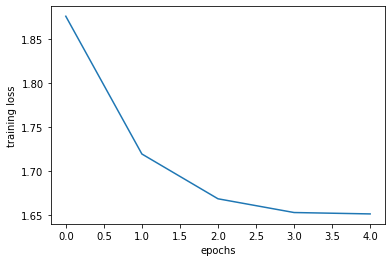

In [285]:
plt.plot(np.arange(EPOCHS), train_losses)
plt.xlabel('epochs')
plt.ylabel('training loss')

Text(0, 0.5, 'training accuracy')

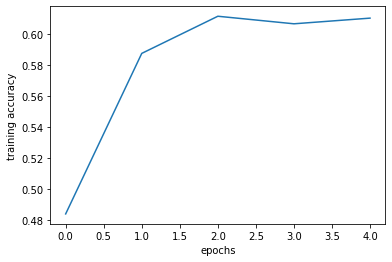

In [286]:
plt.plot(np.arange(EPOCHS), train_accs)
plt.xlabel('epochs')
plt.ylabel('training accuracy')

In [287]:
# Final training loss and evaluation
predictions = mnl_model(X_train.to_numpy())
loss_object.set_avail_data(X_train.to_numpy(), output_categories, avail_variable_indexer)

print(f"Final Training Loss: {loss_object(y_train, predictions).numpy():.3f}")
print(f"Final Training Accuracy: {train_accuracy(y_train, predictions).numpy()*100:.3f} %")

print(f"Final Training Precision: {precision(y_train, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")
print(f"Final Training Recall: {recall(y_train, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")
print(f"Final Training F-1 score: {f1_score(y_train, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")

Final Training Loss: 1.012
Final Training Accuracy: 62.784 %
Final Training Precision: 19.63 %
Final Training Recall: 17.13 %
Final Training F-1 score: 18.29 %


In [288]:
# Final testing loss and evaluation
predictions = mnl_model(X_test.to_numpy())
loss_object.set_avail_data(X_test.to_numpy(), output_categories, avail_variable_indexer)

print(f"Final Testing Loss: {loss_object(y_test, predictions).numpy():.3f}")
print(f"Final Testing Accuracy: {test_accuracy(y_test, predictions).numpy()*100:.3f} %")

print(f"Final Testing Precision: {precision(y_test, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")
print(f"Final Testing Recall: {recall(y_test, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")
print(f"Final Testing F-1 score: {f1_score(y_test, tf.argmax(predictions, axis=-1).numpy(), average='macro') * 100:.2f} %")

Final Testing Loss: 1.103
Final Testing Accuracy: 63.916 %
Final Testing Precision: 27.32 %
Final Testing Recall: 17.33 %
Final Testing F-1 score: 21.21 %


In [264]:
mnl_model.variables

[<tf.Variable 'mnl_model_10/dense_10/kernel:0' shape=(33, 6) dtype=float32, numpy=
 array([[-2.83028454e-01,  6.11393601e-02,  5.47381565e-02,
          8.18218216e-02,  9.10535678e-02,  9.81394351e-02],
        [-3.71907383e-01,  3.82056795e-02,  1.14499971e-01,
         -6.39797226e-02,  1.90136924e-01,  5.10914177e-02],
        [-1.68637440e-01,  2.02850089e-03, -5.90809621e-03,
          4.17679828e-03, -4.18702979e-03, -1.23175895e-02],
        [ 7.62110651e-02, -2.10043222e-01,  3.03175390e-01,
          2.08674669e-02,  1.46205619e-01,  2.42443904e-01],
        [ 5.25586046e-02,  2.07885474e-01, -1.69423427e-02,
          1.96358427e-01, -1.45986021e-01,  3.89288515e-01],
        [ 6.72280267e-02, -2.97580481e-01, -1.00149743e-01,
          1.05809271e-01, -8.79384694e-04,  5.19819893e-02],
        [-1.37752414e-01,  1.57321379e-01, -1.79755181e-01,
         -2.53750890e-01,  2.69407868e-01,  4.55216579e-02],
        [-1.35485351e-01, -3.81949544e-01,  2.16748610e-01,
         -